In [2]:
# ----------------------------------------
# Import required libraries
# ----------------------------------------
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

# Import custom data simulation function
from src.data_simulation import generate_demand_data

# ----------------------------------------
# Generate synthetic demand dataset
# This simulates real-world demand with external factors
# ----------------------------------------
df = generate_demand_data()

# Preview the dataset structure
df.head()

,product,week,demand,supply_shock,event,cost
0,A,0,13.064972,0,0,50.919278
1,A,1,23.100278,0,0,52.889486
2,A,2,13.927464,1,0,60.673206
3,A,3,32.918432,0,0,51.134244
4,A,4,18.824699,0,0,58.277308


In [3]:
# ----------------------------------------
# Create lag features
# These capture temporal dependency (past demand influences future demand)
# ----------------------------------------
df['lag_1'] = df.groupby('product')['demand'].shift(1)
df['lag_2'] = df.groupby('product')['demand'].shift(2)

# ----------------------------------------
# Create moving average baseline
# This serves as a simple benchmark model for comparison
# ----------------------------------------
df['ma_4'] = df.groupby('product')['demand'].transform(
	lambda x: x.rolling(4).mean()
)

# ----------------------------------------
# Remove rows with missing values caused by lagging
# ----------------------------------------
df_model = df.dropna().copy()

In [4]:
# ----------------------------------------
# Define input features
# Includes both historical demand and external signals
# ----------------------------------------
features = ['lag_1', 'lag_2', 'supply_shock', 'event', 'cost']

# Split into input (X) and target (y)
X = df_model[features]
y = df_model['demand']

# ----------------------------------------
# Train a linear regression model
# This combines internal and external factors for prediction
# ----------------------------------------
model = LinearRegression()
model.fit(X, y)

# Generate predictions
df_model['pred_lr'] = model.predict(X)

In [5]:
# ----------------------------------------
# Compute prediction errors
# - Moving average (baseline)
# - Linear regression (model)
# ----------------------------------------
df_model['error_ma'] = abs(df_model['demand'] - df_model['ma_4'])
df_model['error_lr'] = abs(df_model['demand'] - df_model['pred_lr'])

# ----------------------------------------
# Compare average error across products
# This helps evaluate model performance and variability
# ----------------------------------------
error_summary = df_model.groupby('product')[['error_ma', 'error_lr']].mean()

print(error_summary)

         error_ma  error_lr
product                    
A        5.780477  5.693742
B        5.935216  5.839275
C        7.994814  9.785260
D        5.760039  5.611181
E        7.823880  9.095944


In [6]:
# ----------------------------------------
# Use prediction error as a proxy for uncertainty
# Higher error = harder to forecast
# ----------------------------------------
uncertainty = df_model.groupby('product')['error_lr'].mean()

# Rank products by uncertainty
high_uncertainty = uncertainty.sort_values(ascending=False)

print("High uncertainty products:")
print(high_uncertainty)

High uncertainty products:
product
C    9.785260
E    9.095944
B    5.839275
A    5.693742
D    5.611181
Name: error_lr, dtype: float64


In [7]:
# ----------------------------------------
# Analyze how external events affect prediction error
# This shows whether the model struggles under certain conditions
# ----------------------------------------
event_impact = df_model.groupby('event')['error_lr'].mean()

print("Error under normal vs event conditions:")
print(event_impact)

Error under normal vs event conditions:
event
0    7.289960
1    6.498297
Name: error_lr, dtype: float64


In [8]:
# ----------------------------------------
# Convert uncertainty into safety stock recommendation
# Higher uncertainty → more buffer inventory needed
# ----------------------------------------
safety_stock = uncertainty * 1.5

# Create a summary table for decision-making
inventory_df = pd.DataFrame({
	'avg_error': uncertainty,
	'suggested_safety_stock': safety_stock
})

print(inventory_df)

         avg_error  suggested_safety_stock
product                                   
A         5.693742                8.540614
B         5.839275                8.758912
C         9.785260               14.677890
D         5.611181                8.416771
E         9.095944               13.643916


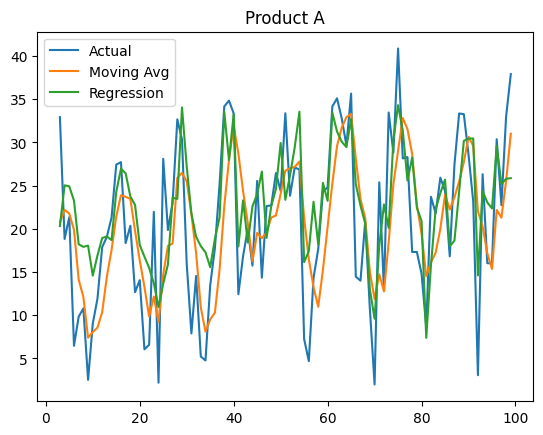

In [9]:
# ----------------------------------------
# Visualize actual vs predicted demand
# Compare baseline vs regression model performance
# ----------------------------------------
for p in ['A']:
	temp = df_model[df_model['product'] == p]

	plt.figure()

	# Actual demand
	plt.plot(temp['week'], temp['demand'], label='Actual')

	# Moving average baseline
	plt.plot(temp['week'], temp['ma_4'], label='Moving Avg')

	# Regression predictions
	plt.plot(temp['week'], temp['pred_lr'], label='Regression')

	plt.title(f'Product {p}')
	plt.legend()
	plt.show()